In [1]:
import pandas as pd
import matplotlib.pyplot as plt

c:\Python\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Forecasting Model for HDAM - Kastraki plant

In [2]:
# Load the weather CSV file into a DataFrame
weather_HDAM_df = pd.read_csv("../data/weather_HDAM.csv")

In [3]:
# Load the generation CSV file into separate DataFrames
generation_HDAM_2022_df = pd.read_csv("../data/timeseries_2022.csv")
generation_HDAM_2023_df = pd.read_csv("../data/timeseries_2023.csv")
generation_HDAM_2024_df = pd.read_csv("../data/timeseries_2024.csv")

In [4]:
# Consolidate all generation DataFrames into one
generation_df = pd.concat([generation_HDAM_2022_df, generation_HDAM_2023_df, generation_HDAM_2024_df], ignore_index=True)

# Filter the consolidated DataFrame to keep only rows where plant_name is "KASTRAKI"
generation_kastraki_df = generation_df[generation_df['plant_name'] == 'KASTRAKI'].copy()  # Explicitly create a copy

# Extract the timestamp from the 'start_time' and 'position' columns
generation_kastraki_df['timestamp'] = pd.to_datetime(generation_kastraki_df['start_time']) + pd.to_timedelta(
    generation_kastraki_df['position'], unit='h'
)

# Format the 'timestamp' column as 'YYYY-MM-DD HH:MM'
generation_kastraki_df['timestamp'] = generation_kastraki_df['timestamp'].dt.strftime('%Y-%m-%d %H:%M')

# Display the first few rows of the updated DataFrame
print(generation_kastraki_df[['start_time', 'position', 'timestamp']].head())

            start_time  position         timestamp
207  2022-01-01T00:00Z         1  2022-01-01 01:00
208  2022-01-01T00:00Z         2  2022-01-01 02:00
209  2022-01-01T00:00Z         3  2022-01-01 03:00
210  2022-01-01T00:00Z         4  2022-01-01 04:00
211  2022-01-01T00:00Z         5  2022-01-01 05:00


In [5]:
# Extract the timestamp from the 'date' column
weather_HDAM_df['timestamp'] = pd.to_datetime(weather_HDAM_df['date'])

# Format the 'timestamp' column as 'YYYY-MM-DD HH:MM'
weather_HDAM_df['timestamp'] = weather_HDAM_df['timestamp'].dt.strftime('%Y-%m-%d %H:%M')

# Display the first few rows of the updated DataFrame
print(weather_HDAM_df[['date', 'timestamp']].head())

                        date         timestamp
0  2021-12-31 21:00:00+00:00  2021-12-31 21:00
1  2021-12-31 22:00:00+00:00  2021-12-31 22:00
2  2021-12-31 23:00:00+00:00  2021-12-31 23:00
3  2022-01-01 00:00:00+00:00  2022-01-01 00:00
4  2022-01-01 01:00:00+00:00  2022-01-01 01:00


In [6]:
weather_HDAM_df.head()

,date,rain,precipitation,precipitation_probability,apparent_temperature,temperature_2m,evapotranspiration,soil_temperature_0cm,showers,snowfall,snow_depth,timestamp
0,2021-12-31 21:00:00+00:00,0.0,0.0,NaN,7.471656,9.3715,NaN,NaN,0.0,0.0,0.0,2021-12-31 21:00
1,2021-12-31 22:00:00+00:00,0.0,0.0,NaN,3.725250,6.0715,NaN,NaN,0.0,0.0,0.0,2021-12-31 22:00
2,2021-12-31 23:00:00+00:00,0.0,0.0,NaN,3.304805,5.6215,NaN,NaN,0.0,0.0,0.0,2021-12-31 23:00
3,2022-01-01 00:00:00+00:00,0.0,0.0,NaN,2.857551,5.6215,NaN,NaN,0.0,0.0,0.0,2022-01-01 00:00
4,2022-01-01 01:00:00+00:00,0.0,0.0,NaN,2.392103,5.1215,NaN,NaN,0.0,0.0,0.0,2022-01-01 01:00


In [7]:
generation_kastraki_df.head()

,plant_name,psr_type,start_time,end_time,position,Generation (MW),timestamp
207,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,1,139.0,2022-01-01 01:00
208,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,2,70.0,2022-01-01 02:00
209,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,3,70.0,2022-01-01 03:00
210,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,4,70.0,2022-01-01 04:00
211,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,5,76.0,2022-01-01 05:00


In [8]:
# Merge the two DataFrames on the 'timestamp' column using an outer join
combined_df = pd.merge(weather_HDAM_df, generation_kastraki_df, on='timestamp', how='inner')

# Display the first few rows of the combined DataFrame
print(combined_df.head())

                        date  rain  precipitation  precipitation_probability  \
0  2022-01-01 01:00:00+00:00   0.0            0.0                        NaN   
1  2022-01-01 02:00:00+00:00   0.0            0.0                        NaN   
2  2022-01-01 03:00:00+00:00   0.0            0.0                        NaN   
3  2022-01-01 04:00:00+00:00   0.0            0.0                        NaN   
4  2022-01-01 05:00:00+00:00   0.0            0.0                        NaN   

   apparent_temperature  temperature_2m  evapotranspiration  \
0              2.392103          5.1215                 NaN   
1              2.410219          5.0215                 NaN   
2              3.151335          5.4215                 NaN   
3              3.859724          5.9215                 NaN   
4              2.683826          4.9715                 NaN   

   soil_temperature_0cm  showers  snowfall  snow_depth         timestamp  \
0                   NaN      0.0       0.0         0.0  2022-01-

In [9]:
combined_df.columns

Index(['date', 'rain', 'precipitation', 'precipitation_probability',
       'apparent_temperature', 'temperature_2m', 'evapotranspiration',
       'soil_temperature_0cm', 'showers', 'snowfall', 'snow_depth',
       'timestamp', 'plant_name', 'psr_type', 'start_time', 'end_time',
       'position', 'Generation (MW)'],
      dtype='object')

---------------EXPLORATORY DATA ANALYSIS (EDA)---------------

Dropping uneccesary information

In [10]:
# Drop the specified columns from combined_df
combined_df = combined_df.drop(columns=['start_time', 'end_time', 'position', 'date', 'psr_type', 'plant_name'])

In [11]:
# Reorder columns to make 'timestamp' the first column and 'Generation (MW)' the second column
columns = ['timestamp', 'Generation (MW)'] + [col for col in combined_df.columns if col not in ['timestamp', 'Generation (MW)']]
combined_df = combined_df[columns]

In [12]:
# Count the number of rows in combined_df
row_count = combined_df.shape[0]

# Print the row count
print(f"The combined DataFrame has {row_count} rows.")

The combined DataFrame has 24771 rows.


In [13]:
# Check for NaN values in the DataFrame
nan_counts = combined_df.isnull().sum()

# Display the count of NaN values for each column
print("NaN values in each column:")
print(nan_counts)

NaN values in each column:
timestamp                        0
Generation (MW)                  0
rain                             0
precipitation                    0
precipitation_probability    24771
apparent_temperature             0
temperature_2m                   0
evapotranspiration           24771
soil_temperature_0cm         24771
showers                          0
snowfall                         0
snow_depth                     483
dtype: int64


In [14]:
combined_df.columns

Index(['timestamp', 'Generation (MW)', 'rain', 'precipitation',
       'precipitation_probability', 'apparent_temperature', 'temperature_2m',
       'evapotranspiration', 'soil_temperature_0cm', 'showers', 'snowfall',
       'snow_depth'],
      dtype='object')

In [15]:
# Drop the specified columns from combined_df
combined_df = combined_df.drop(columns=['precipitation_probability', 'evapotranspiration', 'soil_temperature_0cm'])

# Display the updated DataFrame's columns
print("Updated columns in combined_df:")
print(combined_df.columns)

Updated columns in combined_df:
Index(['timestamp', 'Generation (MW)', 'rain', 'precipitation',
       'apparent_temperature', 'temperature_2m', 'showers', 'snowfall',
       'snow_depth'],
      dtype='object')


In [16]:
# Convert 'timestamp' back to datetime format if it's not already
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# Extract the date from the 'timestamp' column
combined_df['date'] = combined_df['timestamp'].dt.date

# Group by 'date' and calculate the sum of 'Generation (MW)'
daily_generation_df = combined_df.groupby('date')['Generation (MW)'].sum().reset_index()

# Display the first few rows of the new DataFrame
print(daily_generation_df.head())

         date  Generation (MW)
0  2022-01-01           4952.0
1  2022-01-02           3547.0
2  2022-01-03           5014.0
3  2022-01-04           5125.0
4  2022-01-05           5103.0


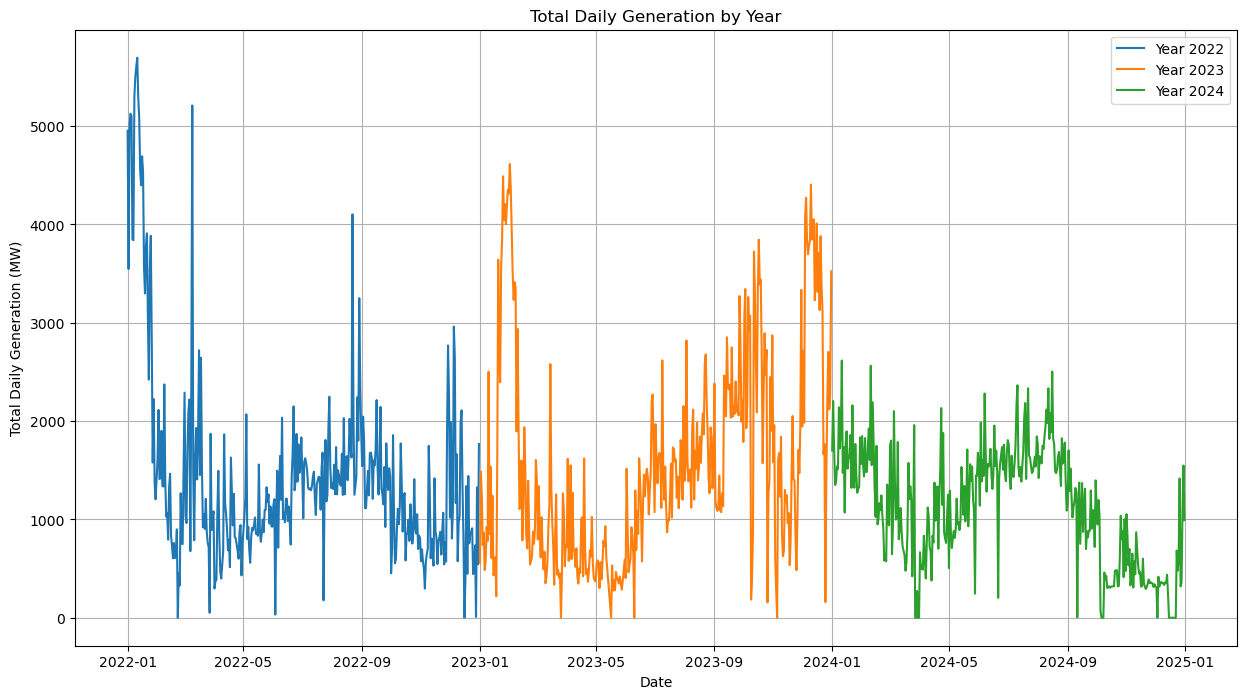

In [17]:
# Extract the year from the 'date' column
daily_generation_df['year'] = pd.to_datetime(daily_generation_df['date']).dt.year

# Group the data by year
years = daily_generation_df['year'].unique()

# Plot daily generation for each year
plt.figure(figsize=(15, 8))
for year in years:
    yearly_data = daily_generation_df[daily_generation_df['year'] == year]
    plt.plot(yearly_data['date'], yearly_data['Generation (MW)'], label=f'Year {year}')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation by Year')
plt.legend()
plt.grid(True)
plt.show()

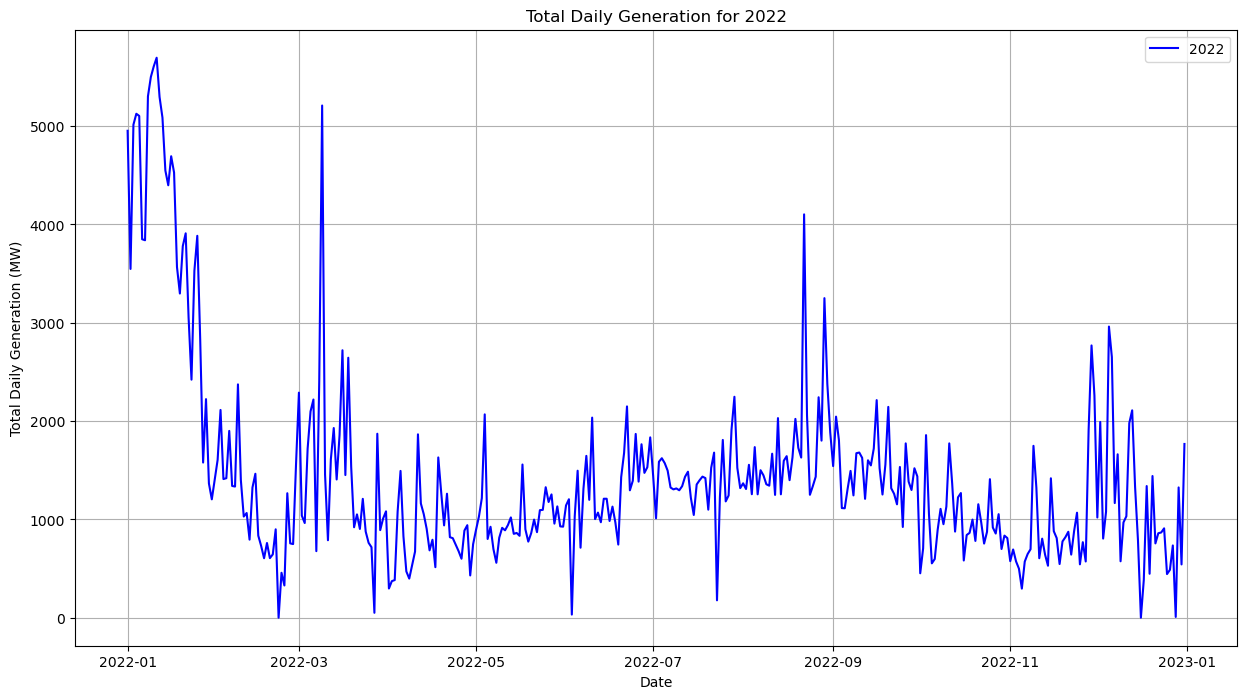

In [18]:
# Filter the DataFrame for 2022
generation_2022 = daily_generation_df[daily_generation_df['year'] == 2022]

# Plot the daily generation for 2023
plt.figure(figsize=(15, 8))
plt.plot(generation_2022['date'], generation_2022['Generation (MW)'], label='2022', color='blue')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation for 2022')
plt.legend()
plt.grid(True)
plt.show()

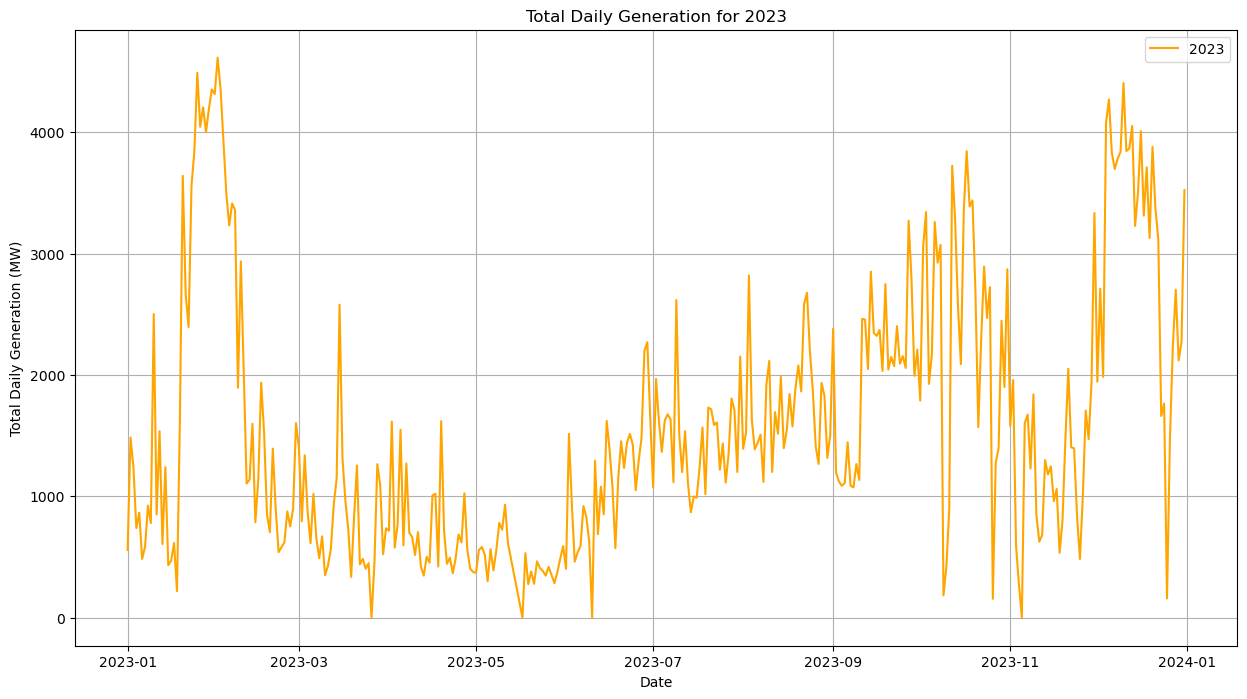

In [19]:
# Filter the DataFrame for 2023
generation_2023 = daily_generation_df[daily_generation_df['year'] == 2023]

# Plot the daily generation for 2023
plt.figure(figsize=(15, 8))
plt.plot(generation_2023['date'], generation_2023['Generation (MW)'], label='2023', color='orange')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation for 2023')
plt.legend()
plt.grid(True)
plt.show()

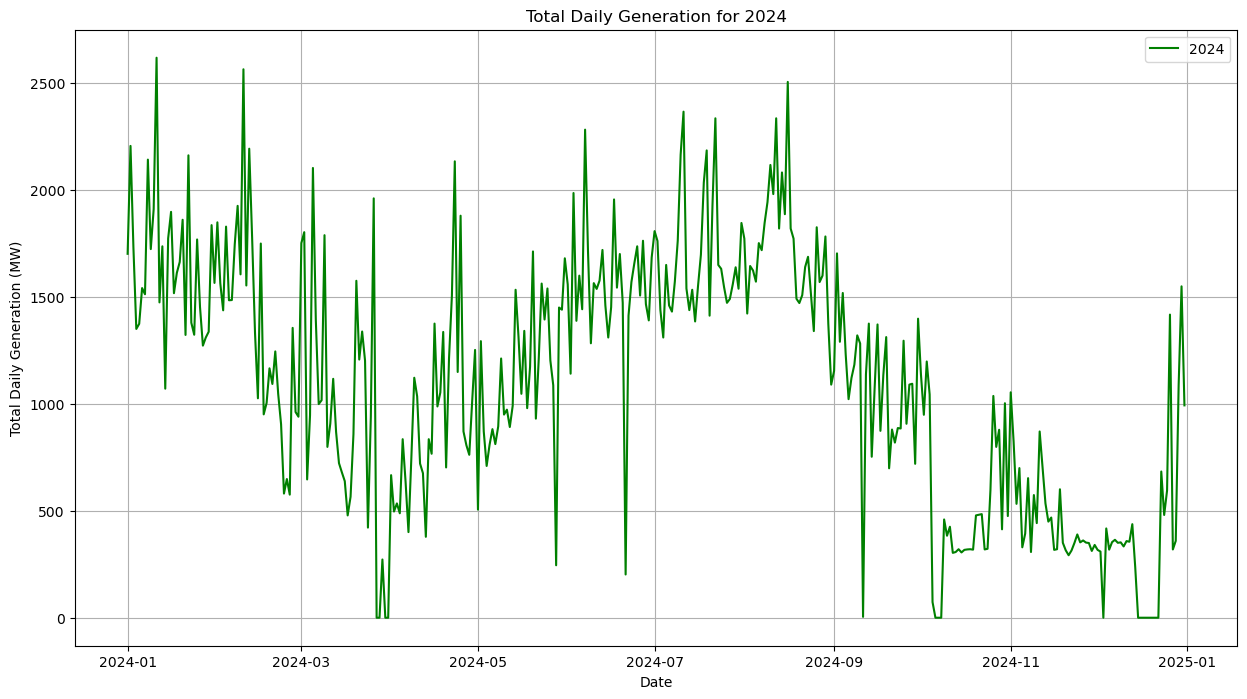

In [20]:
# Filter the DataFrame for 2024
generation_2024 = daily_generation_df[daily_generation_df['year'] == 2024]

# Plot the daily generation for 2024
plt.figure(figsize=(15, 8))
plt.plot(generation_2024['date'], generation_2024['Generation (MW)'], label='2024', color='green')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation for 2024')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Count rows for each year
rows_2022 = generation_2022.shape[0]
rows_2023 = generation_2023.shape[0]
rows_2024 = generation_2024.shape[0]

print(f"Number of rows in 2022 data: {rows_2022}")
print(f"Number of rows in 2023 data: {rows_2023}")
print(f"Number of rows in 2024 data: {rows_2024}")

Number of rows in 2022 data: 364
Number of rows in 2023 data: 361
Number of rows in 2024 data: 366


In [22]:
# Create copy of DataFrames first to avoid the SettingWithCopyWarning
generation_2022_copy = generation_2022.copy()
generation_2023_copy = generation_2023.copy()
generation_2024_copy = generation_2024.copy()

# Create complete date ranges for each year
date_range_2022 = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')
date_range_2023 = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
date_range_2024 = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')

# Convert dates to datetime format on the copies
generation_2022_copy['date'] = pd.to_datetime(generation_2022_copy['date'])
generation_2023_copy['date'] = pd.to_datetime(generation_2023_copy['date'])
generation_2024_copy['date'] = pd.to_datetime(generation_2024_copy['date'])

# Find missing dates for each year
missing_2022 = set(date_range_2022) - set(generation_2022_copy['date'])
missing_2023 = set(date_range_2023) - set(generation_2023_copy['date'])
missing_2024 = set(date_range_2024) - set(generation_2024_copy['date'])

print("Missing dates in 2022:")
for date in sorted(missing_2022):
    print(date.strftime('%Y-%m-%d'))

print("\nMissing dates in 2023:")
for date in sorted(missing_2023):
    print(date.strftime('%Y-%m-%d'))

print("\nMissing dates in 2024:")
for date in sorted(missing_2024):
    print(date.strftime('%Y-%m-%d'))

Missing dates in 2022:
2022-04-24

Missing dates in 2023:
2023-05-13
2023-05-14
2023-05-15
2023-05-16

Missing dates in 2024:


In [32]:
combined_df

,timestamp,Generation (MW),rain,precipitation,apparent_temperature,temperature_2m,showers,snowfall,snow_depth,date
0,2022-01-01 01:00:00,139.0,0.0,0.0,2.392103,5.121500,0.0,0.0,0.0,2022-01-01
1,2022-01-01 02:00:00,70.0,0.0,0.0,2.410219,5.021500,0.0,0.0,0.0,2022-01-01
2,2022-01-01 03:00:00,70.0,0.0,0.0,3.151335,5.421500,0.0,0.0,0.0,2022-01-01
3,2022-01-01 04:00:00,70.0,0.0,0.0,3.859724,5.921500,0.0,0.0,0.0,2022-01-01
4,2022-01-01 05:00:00,76.0,0.0,0.0,2.683826,4.971500,0.0,0.0,0.0,2022-01-01
...,...,...,...,...,...,...,...,...,...,...
24766,2024-12-31 16:00:00,131.0,0.0,0.0,9.010325,9.921500,0.0,0.0,0.0,2024-12-31
24767,2024-12-31 17:00:00,157.0,0.0,0.0,7.855658,8.771501,0.0,0.0,0.0,2024-12-31
24768,2024-12-31 18:00:00,157.0,0.0,0.0,6.662304,7.671500,0.0,0.0,0.0,2024-12-31
24769,2024-12-31 19:00:00,157.0,0.0,0.0,5.490203,6.621500,0.0,0.0,0.0,2024-12-31


In [23]:

nan_counts = combined_df.isnull().sum()
total_nan = combined_df.isnull().sum().sum()
print(f"Total NaN values in the dataset: {total_nan}")

# Identify columns with NaN values
columns_with_nans = nan_counts[nan_counts > 0]
if len(columns_with_nans) > 0:
    print("\nColumns containing NaN values:")
    for col, count in columns_with_nans.items():
        percentage = (count / len(combined_df)) * 100
        print(f"{col}: {count} NaNs ({percentage:.2f}%)")
else:
    print("\nNo columns contain NaN values.")

# Find specific rows with NaN values (limit to first 20 for readability)
if total_nan > 0:
    print("\nSample rows containing NaN values:")
    nan_rows = combined_df[combined_df.isnull().any(axis=1)]
    display(nan_rows.head(20))

Total NaN values in the dataset: 483

Columns containing NaN values:
snow_depth: 483 NaNs (1.95%)

Sample rows containing NaN values:


,timestamp,Generation (MW),rain,precipitation,apparent_temperature,temperature_2m,showers,snowfall,snow_depth,date
20956,2024-07-18 01:00:00,0.0,0.0,0.0,26.941425,25.821500,0.0,0.0,NaN,2024-07-18
20957,2024-07-18 02:00:00,1.0,0.0,0.0,26.508333,25.721500,0.0,0.0,NaN,2024-07-18
20958,2024-07-18 03:00:00,16.0,0.0,0.0,26.165956,25.471500,0.0,0.0,NaN,2024-07-18
20959,2024-07-18 04:00:00,20.0,0.0,0.0,26.372229,25.671501,0.0,0.0,NaN,2024-07-18
20960,2024-07-18 05:00:00,32.0,0.0,0.0,28.319756,27.821500,0.0,0.0,NaN,2024-07-18
20961,2024-07-18 06:00:00,32.0,0.0,0.0,32.572140,31.471500,0.0,0.0,NaN,2024-07-18
20962,2024-07-18 07:00:00,16.0,0.0,0.0,35.220837,35.121502,0.0,0.0,NaN,2024-07-18
20963,2024-07-18 08:00:00,0.0,0.0,0.0,36.628334,37.071500,0.0,0.0,NaN,2024-07-18
20964,2024-07-18 09:00:00,0.0,0.0,0.0,38.485046,38.421500,0.0,0.0,NaN,2024-07-18
20965,2024-07-18 10:00:00,0.0,0.0,0.0,39.146854,39.521500,0.0,0.0,NaN,2024-07-18


In [24]:
# Check if 'snow_depth' exists in the DataFrame before dropping
if 'snow_depth' in combined_df.columns:
    # Drop the snow_depth column
    combined_df = combined_df.drop(columns=['snow_depth'])
    print("snow_depth column dropped successfully.")
    
    # Display the updated columns to confirm
    print("\nUpdated columns in combined_df:")
    print(combined_df.columns.tolist())
else:
    print("snow_depth column does not exist in the DataFrame.")

# Check for NaN values after dropping the column
nan_counts = combined_df.isnull().sum()
total_nan = combined_df.isnull().sum().sum()
print(f"\nTotal NaN values in the dataset after dropping snow_depth: {total_nan}")

# Display columns with NaN values
columns_with_nans = nan_counts[nan_counts > 0]
if len(columns_with_nans) > 0:
    print("\nColumns still containing NaN values:")
    for col, count in columns_with_nans.items():
        percentage = (count / len(combined_df)) * 100
        print(f"{col}: {count} NaNs ({percentage:.2f}%)")
else:
    print("\nNo columns contain NaN values after dropping snow_depth.")

snow_depth column dropped successfully.

Updated columns in combined_df:
['timestamp', 'Generation (MW)', 'rain', 'precipitation', 'apparent_temperature', 'temperature_2m', 'showers', 'snowfall', 'date']

Total NaN values in the dataset after dropping snow_depth: 0

No columns contain NaN values after dropping snow_depth.


Forecasting Model Build

In [25]:
# Convert timestamp to datetime if not already
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# Sort the dataframe by timestamp
combined_df = combined_df.sort_values('timestamp')

# Calculate the split point (e.g., using the last 20% as test data)
split_point = int(len(combined_df) * 0.8)

# Create train and test sets
train_df = combined_df.iloc[:split_point]
test_df = combined_df.iloc[split_point:]

# Print the shapes to verify the split
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# Print the date ranges for both sets
print("\nTraining data range:", 
      train_df['timestamp'].min().strftime('%Y-%m-%d'), "to", 
      train_df['timestamp'].max().strftime('%Y-%m-%d'))
print("Test data range:", 
      test_df['timestamp'].min().strftime('%Y-%m-%d'), "to", 
      test_df['timestamp'].max().strftime('%Y-%m-%d'))

Training set shape: (19816, 9)
Test set shape: (4955, 9)

Training data range: 2022-01-01 to 2024-05-27
Test data range: 2024-05-27 to 2024-12-31


In [26]:
# Prepare features (X) and target (y)
# Drop non-feature columns
feature_columns = [col for col in train_df.columns if col not in ['timestamp', 'Generation (MW)', 'date']]
X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df['Generation (MW)']
y_test = test_df['Generation (MW)']

Random Forest

Model Performance Metrics:
RMSE: 86.28
R2 Score: -0.18


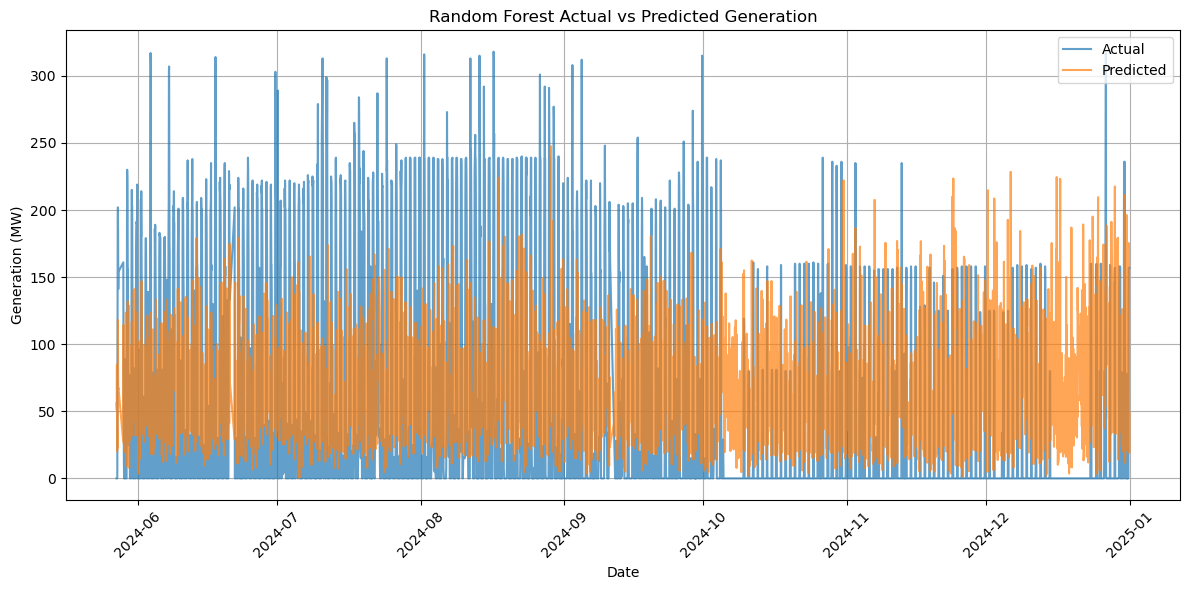


Feature Importance:
                feature  importance
2  apparent_temperature    0.620850
3        temperature_2m    0.322319
1         precipitation    0.028645
0                  rain    0.028049
5              snowfall    0.000138
4               showers    0.000000


In [27]:
# Import required libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_df['timestamp'], y_test, label='Actual', alpha=0.7)
plt.plot(test_df['timestamp'], y_pred, label='Predicted', alpha=0.7)
plt.title('Random Forest Actual vs Predicted Generation')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

XGBoost

XGBoost Model Performance Metrics:
RMSE: 80.03
R2 Score: -0.01


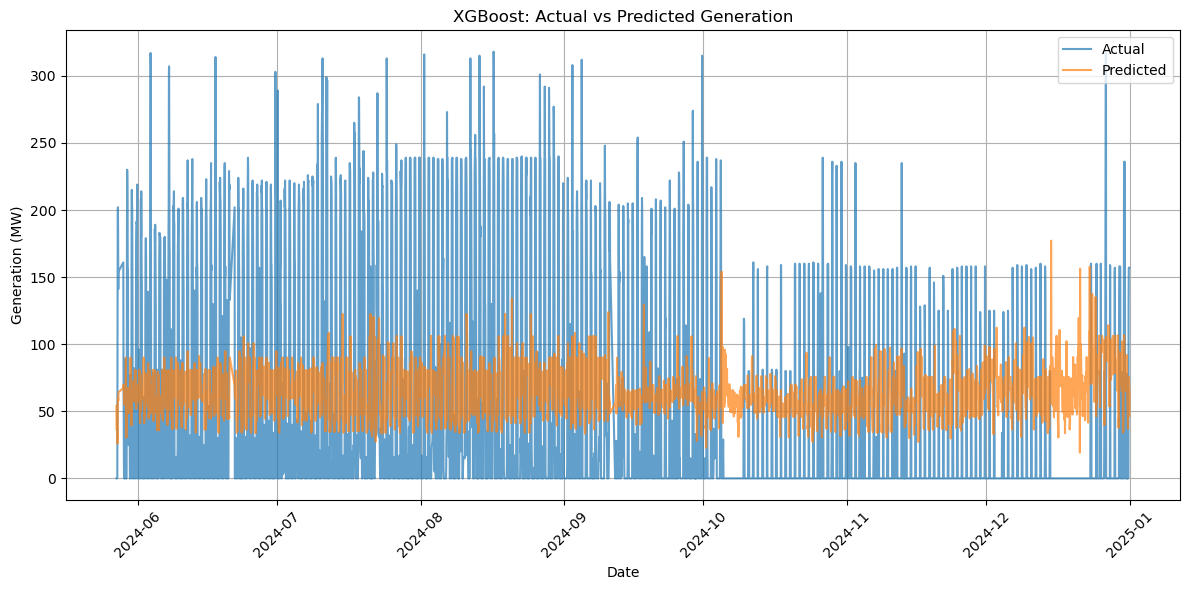


Feature Importance:
                feature  importance
3        temperature_2m    0.336831
2  apparent_temperature    0.252704
0                  rain    0.171461
1         precipitation    0.127928
5              snowfall    0.111075
4               showers    0.000000


In [28]:
# Import required libraries
import xgboost as xgb

# Create and train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_df['timestamp'], y_test, label='Actual', alpha=0.7)
plt.plot(test_df['timestamp'], y_pred, label='Predicted', alpha=0.7)
plt.title('XGBoost: Actual vs Predicted Generation')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

Epoch 1/10
496/496 [==============================] - 10s 10ms/step - loss: 0.0535 - val_loss: 0.0641
Epoch 2/10
496/496 [==============================] - 4s 7ms/step - loss: 0.0519 - val_loss: 0.0642
Epoch 3/10
496/496 [==============================] - 3s 7ms/step - loss: 0.0518 - val_loss: 0.0641
Epoch 4/10
496/496 [==============================] - 3s 6ms/step - loss: 0.0518 - val_loss: 0.0643
Epoch 5/10
496/496 [==============================] - 3s 6ms/step - loss: 0.0518 - val_loss: 0.0640
Epoch 6/10
496/496 [==============================] - 3s 6ms/step - loss: 0.0517 - val_loss: 0.0643
Epoch 7/10
496/496 [==============================] - 3s 6ms/step - loss: 0.0517 - val_loss: 0.0641
Epoch 8/10
496/496 [==============================] - 3s 6ms/step - loss: 0.0517 - val_loss: 0.0641
Epoch 9/10
496/496 [==============================] - 4s 8ms/step - loss: 0.0517 - val_loss: 0.0640
Epoch 10/10
155/155 [==============================] - 1s 3ms/step
LSTM Model Performance Metrics:

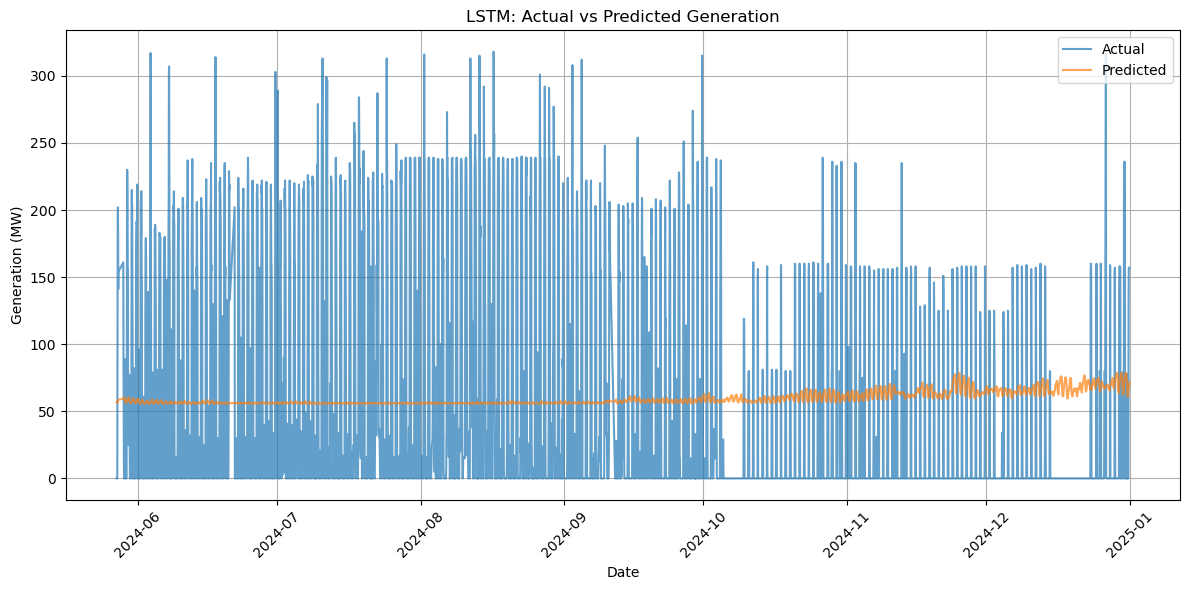

In [30]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Scale the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Reshape data for LSTM [samples, time steps, features]
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train_reshaped, 
    y_train_scaled, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_scaled = model.predict(X_test_reshaped)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("LSTM Model Performance Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_df['timestamp'], y_test, label='Actual', alpha=0.7)
plt.plot(test_df['timestamp'], y_pred, label='Predicted', alpha=0.7)
plt.title('LSTM: Actual vs Predicted Generation')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()